In [8]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json


In [15]:
import json

# Ligas e períodos
ligas = ['CBLOL', 'LEC', 'LCS', 'LCK']
periodos = ['2', '4']

# Gerar lista de arquivos JSON
file_paths = [f'../{liga.lower()}/{liga}{periodo}_results.json' for liga in ligas for periodo in periodos]

# Dicionário para armazenar os dados de todos os arquivos
all_data = {}
sum = 1
# Loop para ler cada arquivo JSON
for file_path in file_paths:
       
    with open(file_path, 'r') as file:
        data = json.load(file)
        all_data.update(data)

# Agora você pode usar all_data, que contém os dados de todos os arquivos
print(all_data)  # Exibe o conteúdo de todos os arquivos JSON



{'CBLOL2': {'Naive Bayes': 0.5, 'Regressao Logistica': 0.5416666666666666, 'SVM': 0.5416666666666666, 'Arvore de Decisao': 0.7083333333333334}, 'CBLOL4': {'Naive Bayes': 0.5208333333333334, 'Regressao Logistica': 0.5416666666666666, 'SVM': 0.6875, 'Arvore de Decisao': 0.5416666666666666}, 'LEC2': {'Naive Bayes': 0.6428571428571429, 'Regressao Logistica': 0.7142857142857143, 'SVM': 0.6428571428571429, 'Arvore de Decisao': 0.5357142857142857}, 'LEC4': {'Naive Bayes': 0.5094339622641509, 'Regressao Logistica': 0.5471698113207547, 'SVM': 0.6037735849056604, 'Arvore de Decisao': 0.5849056603773585}, 'LCS2': {'Naive Bayes': 0.6153846153846154, 'Regressao Logistica': 0.5, 'SVM': 0.6538461538461539, 'Arvore de Decisao': 0.5769230769230769}, 'LCS4': {'Naive Bayes': 0.49122807017543857, 'Regressao Logistica': 0.5789473684210527, 'SVM': 0.6491228070175439, 'Arvore de Decisao': 0.543859649122807}, 'LCK2': {'Naive Bayes': 0.6875, 'Regressao Logistica': 0.4375, 'SVM': 0.6041666666666666, 'Arvore de 

In [16]:
# Exemplo de listas de acurácia para cada modelo
accuracy_logistic = []  
accuracy_svm = []
accuracy_tree = []
accuracy_naive_bayes = []

for key, values in all_data.items():
    if 'Regressao Logistica' in values:
        accuracy_logistic.append(values['Regressao Logistica'])
    if 'SVM' in values:
        accuracy_svm.append(values['SVM'])
    if 'Arvore de Decisao' in values:
        accuracy_tree.append(values['Arvore de Decisao'])
    if 'Naive Bayes' in values:
        accuracy_naive_bayes.append(values['Naive Bayes'])

In [17]:
print(accuracy_logistic)
print(accuracy_svm)
print(accuracy_tree)
print(accuracy_naive_bayes)

[0.5416666666666666, 0.5416666666666666, 0.7142857142857143, 0.5471698113207547, 0.5, 0.5789473684210527, 0.4375, 0.45263157894736844]
[0.5416666666666666, 0.6875, 0.6428571428571429, 0.6037735849056604, 0.6538461538461539, 0.6491228070175439, 0.6041666666666666, 0.6947368421052632]
[0.7083333333333334, 0.5416666666666666, 0.5357142857142857, 0.5849056603773585, 0.5769230769230769, 0.543859649122807, 0.6458333333333334, 0.6526315789473685]
[0.5, 0.5208333333333334, 0.6428571428571429, 0.5094339622641509, 0.6153846153846154, 0.49122807017543857, 0.6875, 0.3894736842105263]


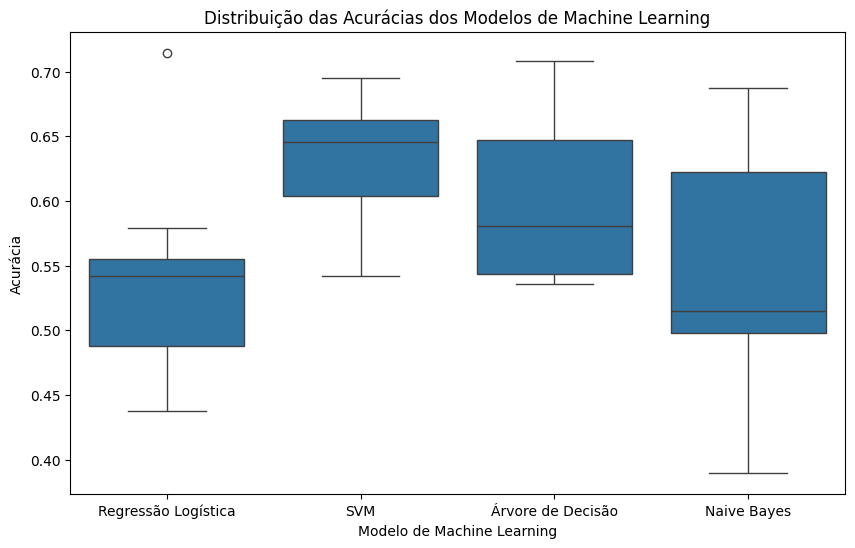

In [18]:
# Expandindo as listas para serem iguais e concatenando-as
data = pd.DataFrame({
    'Modelo': ['Regressão Logística'] * len(accuracy_logistic) +
              ['SVM'] * len(accuracy_svm) +
              ['Árvore de Decisão'] * len(accuracy_tree) +
              ['Naive Bayes'] * len(accuracy_naive_bayes),
    'Acuracia': accuracy_logistic + accuracy_svm + accuracy_tree + accuracy_naive_bayes
})

# Plotando o boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Modelo', y='Acuracia')
plt.title("Distribuição das Acurácias dos Modelos de Machine Learning")
plt.xlabel("Modelo de Machine Learning")
plt.ylabel("Acurácia")
plt.show()